In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../dataset/taxi_trip_pricing.csv")

In [3]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


membaca datset


In [4]:
print("Jumlah baris dan kolom:", df.shape)


Jumlah baris dan kolom: (1000, 11)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    str    
 2   Day_of_Week            950 non-null    str    
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    str    
 5   Weather                950 non-null    str    
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), str(4)
memory usage: 108.5 KB


In [6]:
print(df.columns.tolist())

['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count', 'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']


In [7]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


mengecek missing value


In [8]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

mengecek duplikasi

In [9]:
print("Jumlah data duplikat :", df.duplicated().sum())


Jumlah data duplikat : 0


In [10]:
print(df.columns.tolist())


['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count', 'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    str    
 2   Day_of_Week            950 non-null    str    
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    str    
 5   Weather                950 non-null    str    
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), str(4)
memory usage: 108.5 KB


In [12]:
print(df.columns.tolist())

['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count', 'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']


melihat distribusi target

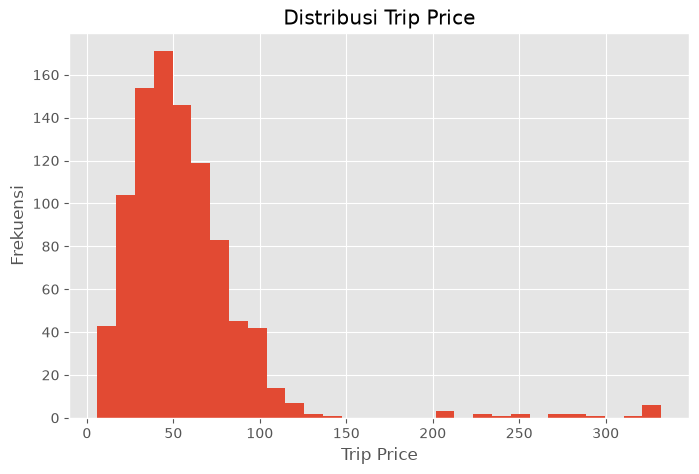

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["Trip_Price"], bins=30)

plt.title("Distribusi Trip Price")
plt.xlabel("Trip Price")
plt.ylabel("Frekuensi")

plt.show()

In [14]:
numeric_df = df.select_dtypes(include=["float64","int64"])

numeric_df.corr()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
Trip_Distance_km,1.000000,-0.048397,0.032218,-0.017041,-0.025902,-0.022102,0.849123
Passenger_Count,-0.048397,1.000000,0.022932,0.030213,0.034068,0.022845,-0.014223
Base_Fare,0.032218,0.022932,1.000000,0.003092,-0.019150,0.012035,0.035533
Per_Km_Rate,-0.017041,0.030213,0.003092,1.000000,0.029241,0.027199,0.275135
Per_Minute_Rate,-0.025902,0.034068,-0.019150,0.029241,1.000000,-0.024230,0.141226
Trip_Duration_Minutes,-0.022102,0.022845,0.012035,0.027199,-0.024230,1.000000,0.221211
Trip_Price,0.849123,-0.014223,0.035533,0.275135,0.141226,0.221211,1.000000


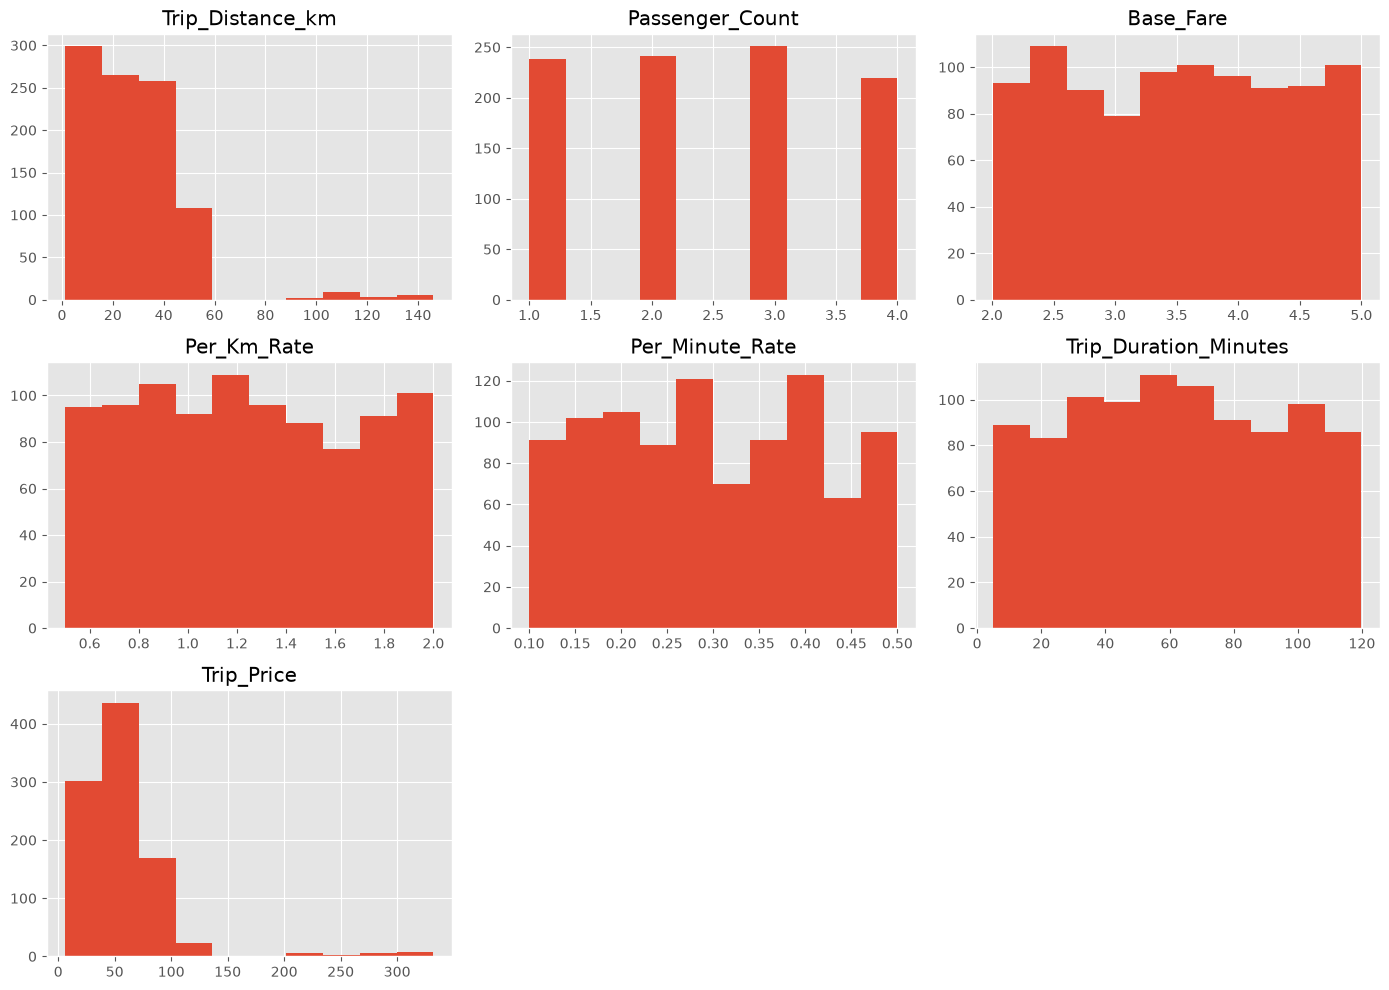

In [15]:
numeric_df.hist(figsize=(14,10))

plt.tight_layout()

plt.show()